# LD distribution

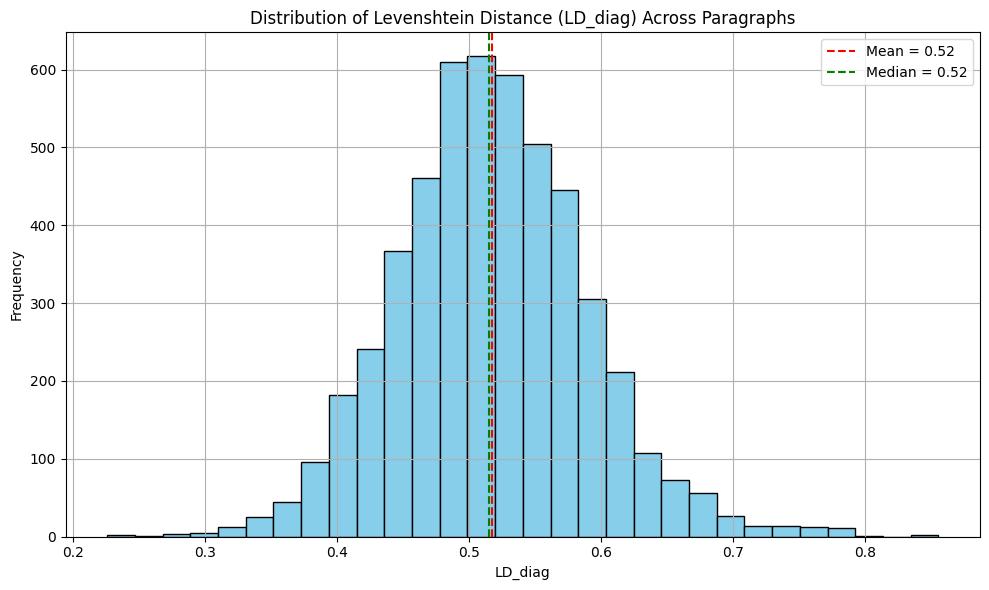

In [29]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('the_dataset_evaluation.json', 'r') as f:
    data = json.load(f)


ld_diag_values = []

for article in data:
    for eval_entry in article['evaluations']:
        ld = eval_entry['LD_diag']
        if ld >0.1: 
            ld_diag_values.append(ld)


mean_ld = np.mean(ld_diag_values)
median_ld = np.median(ld_diag_values)


plt.figure(figsize=(10, 6))
plt.hist(ld_diag_values, bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_ld, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean = {mean_ld:.2f}')
plt.axvline(median_ld, color='green', linestyle='dashed', linewidth=1.5, label=f'Median = {median_ld:.2f}')
plt.title('Distribution of Levenshtein Distance (LD_diag) Across Paragraphs')
plt.xlabel('LD_diag')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("ld_diag_distribution.png", dpi=300, bbox_inches='tight')


plt.show()


plt.close()



# CS_diag vs CS_avg boxplot

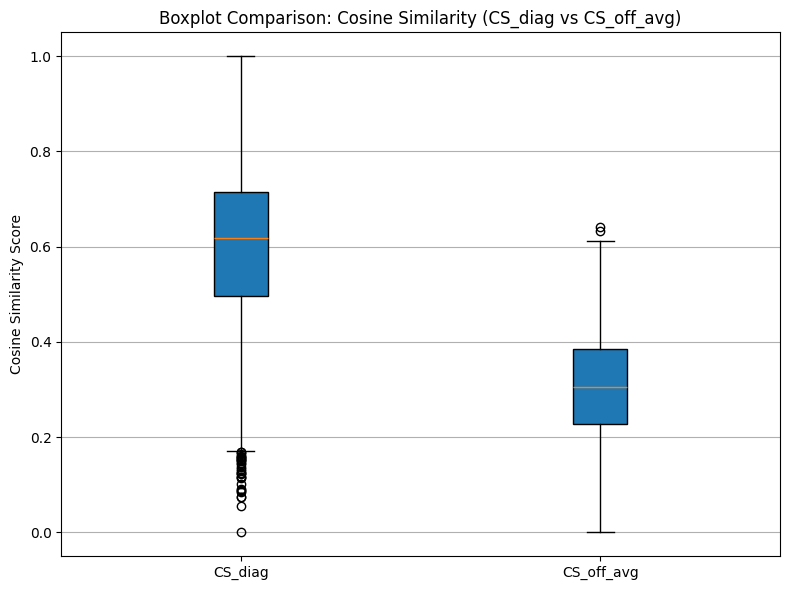

In [30]:
import json
import matplotlib.pyplot as plt


with open('the_dataset_evaluation.json', 'r') as f:
    data = json.load(f)


cs_diag_values = []
cs_off_avg_values = []

for article in data:
    for eval_entry in article['evaluations']:
        cs_d = eval_entry.get('CS_diag')
        cs_o = eval_entry.get('CS_off_avg')
        if cs_d is not None and cs_o is not None:
            cs_diag_values.append(cs_d)
            cs_off_avg_values.append(cs_o)


plt.figure(figsize=(8, 6))
plt.boxplot([cs_diag_values, cs_off_avg_values], tick_labels=['CS_diag', 'CS_off_avg'], patch_artist=True)
plt.title('Boxplot Comparison: Cosine Similarity (CS_diag vs CS_off_avg)')
plt.ylabel('Cosine Similarity Score')
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("CS_Diag_vs_CS_off_avg.png", dpi=300, bbox_inches='tight')


plt.show()


plt.close()


# GPT eval graph

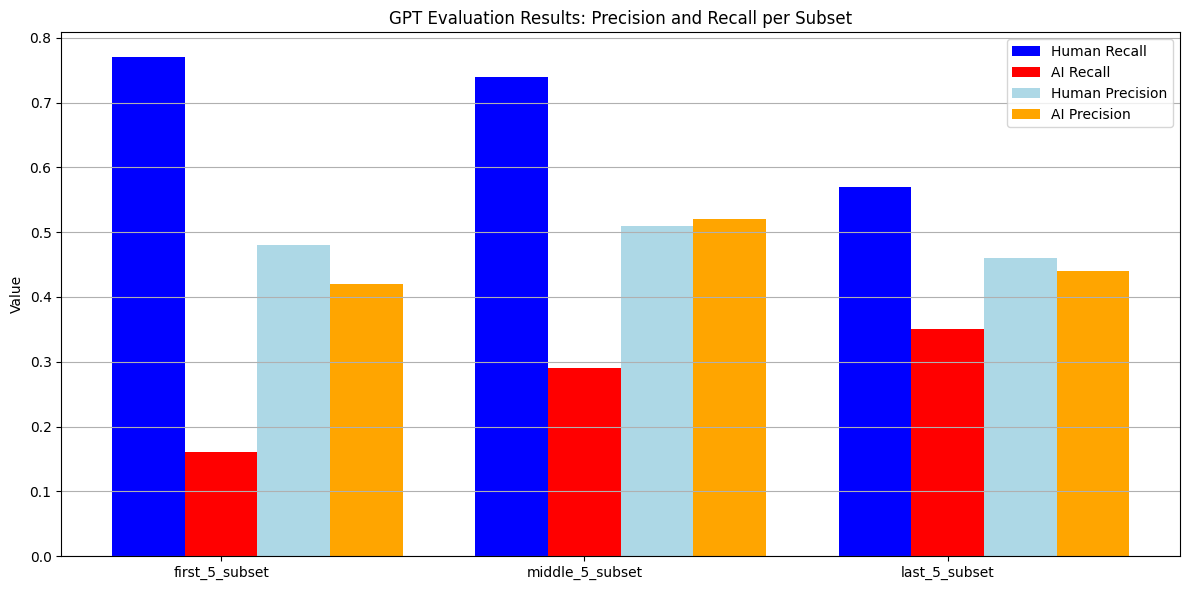

In [37]:
import json
import matplotlib.pyplot as plt
import os


file_names = [
    "first_5_subset_gpt_eval.json",
    "middle_5_subset_gpt_eval.json",
    "last_5_subset_gpt_eval.json"
]


subsets = []
human_precisions = []
human_recalls = []
human_f1s = []

ai_precisions = []
ai_recalls = []
ai_f1s = []


for file in file_names:
    with open(f"{file}", 'r') as f:
        data = json.load(f)
        subset_name = file.replace("_gpt_eval.json", "")
        subsets.append(subset_name)

        human = data["evaluation_summary"]["Human"]
        ai = data["evaluation_summary"]["AI"]

        human_precisions.append(human["precision"])
        human_recalls.append(human["recall"])
        human_f1s.append(human["f1_score"])

        ai_precisions.append(ai["precision"])
        ai_recalls.append(ai["recall"])
        ai_f1s.append(ai["f1_score"])


x = range(len(subsets))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar([i - width for i in x], human_recalls, width=width, label='Human Recall', color='blue')
plt.bar(x, ai_recalls, width=width, label='AI Recall', color='red')
plt.bar([i + width for i in x], human_precisions, width=width, label='Human Precision', color='lightblue')
plt.bar([i + 2*width for i in x], ai_precisions, width=width, label='AI Precision', color='orange')

plt.xticks(ticks=x, labels=subsets)
plt.ylabel("Value")
plt.title("GPT Evaluation Results: Precision and Recall per Subset")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("GPT Evaluation Results.png", dpi=300, bbox_inches='tight')

plt.show()

plt.close()
